
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


## Import Libraries

In [ ]:
# Import required libraries

#Importing Libraries
import pandas as pd
import numpy as np
import time
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)


## Load Dataset

In [ ]:
# Load dataset
url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


## Exploratory Data Analysis

In [ ]:
# Check Type and info
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
# Check missing values

print(df.isnull().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [ ]:
# Rows before removing duplicates

df.count()

,0
Hours Studied,10000
Previous Scores,10000
Extracurricular Activities,10000
Sleep Hours,10000
Sample Question Papers Practiced,10000
Performance Index,10000


In [ ]:
# Check Duplicate values

duplicate_rows_df = df[df.duplicated()]
print('number of duplicate rows: ', duplicate_rows_df.shape)

df = df.drop_duplicates()
df.head(5)

number of duplicate rows:  (127, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
# Rows after removing duplicates

df.count()

,0
Hours Studied,9873
Previous Scores,9873
Extracurricular Activities,9873
Sleep Hours,9873
Sample Question Papers Practiced,9873
Performance Index,9873


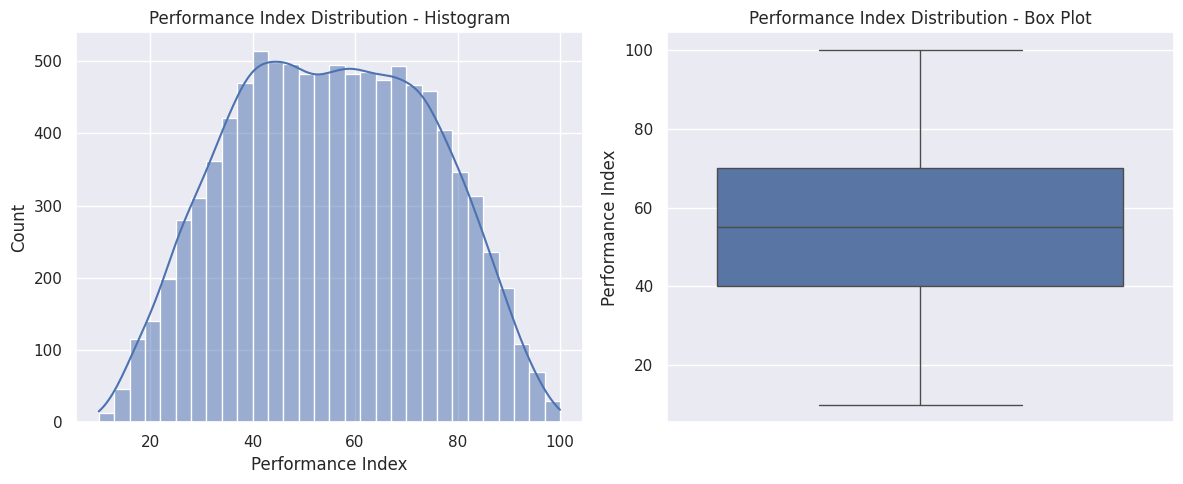

Performance Index Skewness: -0.00
Performance Index Kurotsis: -0.86


In [ ]:
# Distibution Plot

plt.figure(figsize=(12, 5)) #Setting the figure size.

# Left: Histogram
plt.subplot(1, 2, 1)
sns.histplot(df["Performance Index"], kde=True, bins=30)
plt.title("Performance Index Distribution - Histogram")
plt.xlabel("Performance Index", fontsize=12)

# Right: Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Performance Index"])
plt.title("Performance Index Distribution - Box Plot")
plt.ylabel("Performance Index", fontsize=12)

plt.tight_layout()
plt.show()

# Calculating skewness and kurtosis of the price distribution.
skewness = df["Performance Index"].skew()
kurtosis = df["Performance Index"].kurt()
print(f"Performance Index Skewness: {skewness:.2f}")
print(f"Performance Index Kurotsis: {kurtosis:.2f}")

## Encoding (if needed)

In [ ]:
# Encode categorical columns if any

from sklearn.preprocessing import LabelEncoder

categorical_cols = [ 'Extracurricular Activities' ]
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])



In [ ]:
# Convert to Dummy Variable

df_encoded_status = pd.get_dummies(df_encoded,columns=['Extracurricular Activities'],
    drop_first=True
)
# Convert True/False to 0/1
df_encoded_status = df_encoded_status.astype(int)

In [ ]:
df1 = df_encoded_status.copy()
df1.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_1
0,7,99,9,1,91,1
1,4,82,4,2,65,0
2,8,51,7,2,45,1
3,5,52,5,2,36,1
4,7,75,8,5,66,0


## Visualization

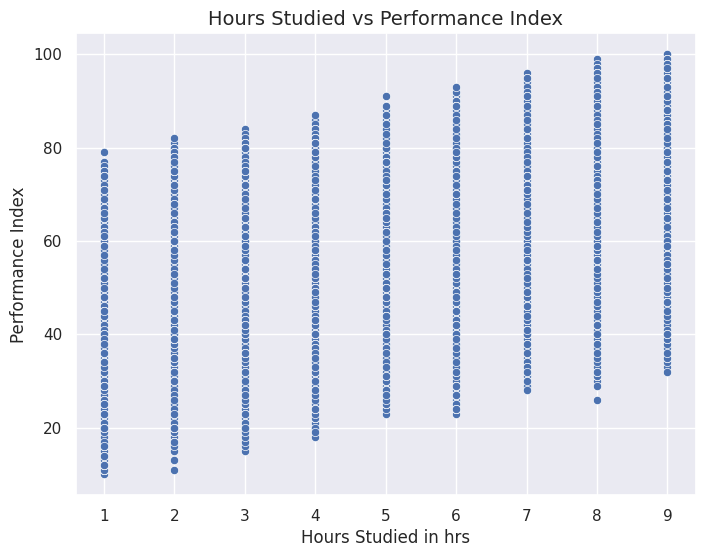

<Axes: >

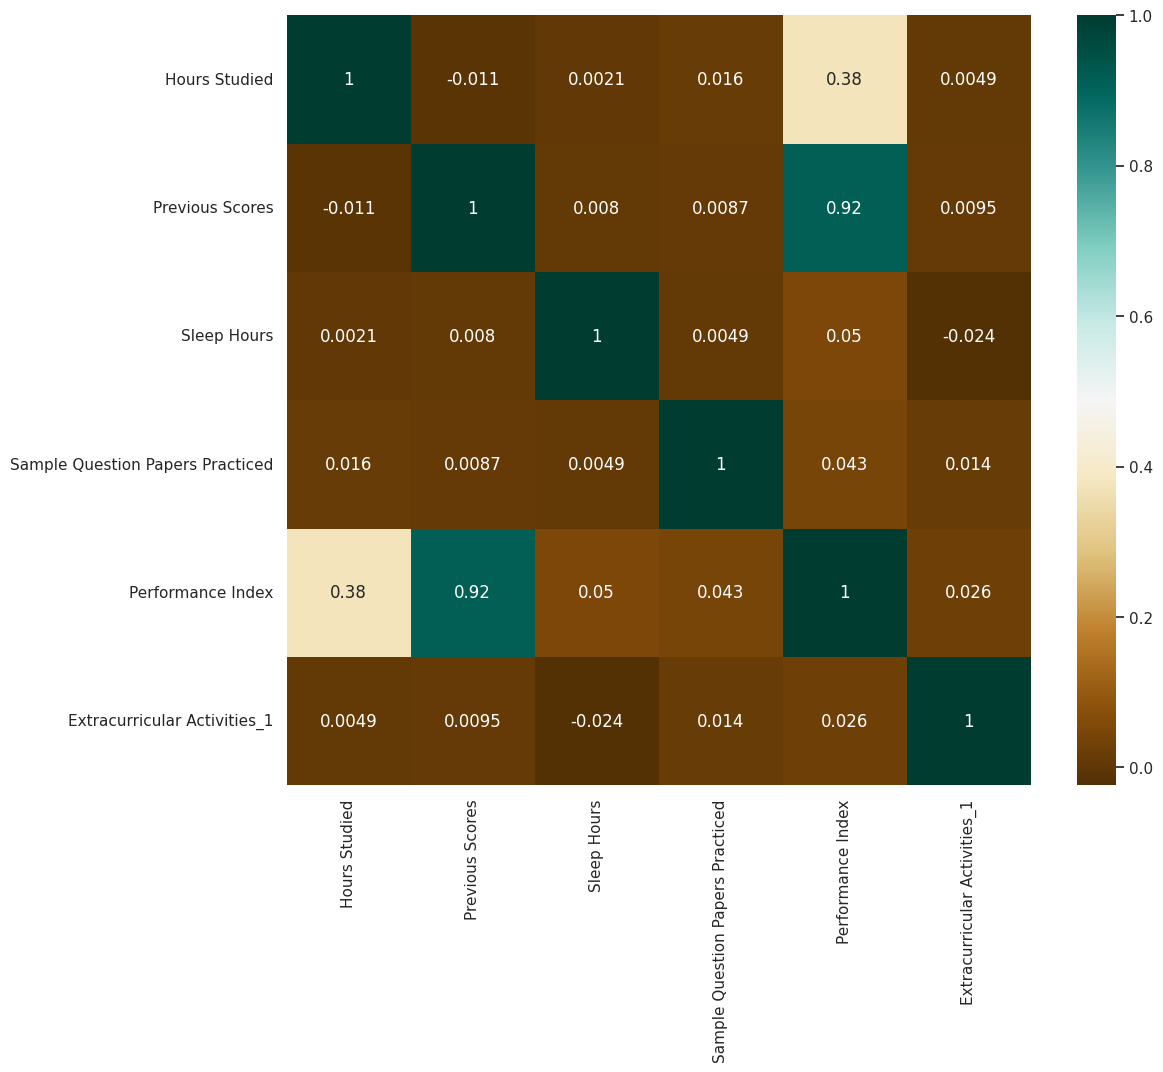

In [ ]:
# Scatter plots
plt.figure(figsize=(8,6))
sns.scatterplot(x="Hours Studied", y="Performance Index", data=df1)
plt.title(f"Hours Studied vs Performance Index", fontsize=14)
plt.xlabel("Hours Studied in hrs", fontsize=12)
plt.ylabel("Performance Index", fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Heatmap
c = df1.corr()
plt.figure(figsize=(12,10))
sns.heatmap(c,cmap="BrBG",annot=True)

## Correlation Analysis

In [ ]:
# Compute correlation matrix

from tabulate import tabulate

corr = df1.corr().round(3)
print(tabulate(corr, headers='keys', tablefmt='grid', floatfmt='.3f'))

+----------------------------------+-----------------+-------------------+---------------+------------------------------------+---------------------+--------------------------------+
|                                  |   Hours Studied |   Previous Scores |   Sleep Hours |   Sample Question Papers Practiced |   Performance Index |   Extracurricular Activities_1 |
+==================================+=================+===================+===============+====================================+=====================+================================+
| Hours Studied                    |           1.000 |            -0.011 |         0.002 |                              0.016 |               0.375 |                          0.005 |
+----------------------------------+-----------------+-------------------+---------------+------------------------------------+---------------------+--------------------------------+
| Previous Scores                  |          -0.011 |             1.000 |         0.

## Train-Test Split

In [ ]:
df1.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_1
0,7,99,9,1,91,1
1,4,82,4,2,65,0
2,8,51,7,2,45,1
3,5,52,5,2,36,1
4,7,75,8,5,66,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

X = df1.drop("Performance Index", axis=1)
y = df1["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## Feature Selection

In [ ]:
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Performance Index   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.230e+05
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:48:29   Log-Likelihood:                -14694.
No. Observations:                6911   AIC:                         2.940e+04
Df Residuals:                    6905   BIC:                         2.944e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [ ]:
p_values = model.pvalues
significant_features = p_values[p_values < 0.05]
print(significant_features)


const                                0.000000e+00
Hours Studied                        0.000000e+00
Previous Scores                      0.000000e+00
Sleep Hours                         9.036971e-220
Sample Question Papers Practiced    3.064194e-110
Extracurricular Activities_1         7.523149e-30
dtype: float64


In [ ]:
# Exclude 'const'
filtered_significant_features_index = [col for col in significant_features.index if col != 'const']
X_train_filtered = X_train[filtered_significant_features_index]
X_test_filtered = X_test[filtered_significant_features_index]


## Feature Scaling (If needed)

In [ ]:
# Scaling after splitting and filtering
numeric_vars = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
numeric_vars = [col for col in numeric_vars if col in X_train_filtered.columns]  # Only scale available cols

scaler = StandardScaler()
X_train_scaled = X_train_filtered.copy()
X_test_scaled = X_test_filtered.copy()

X_train_scaled[numeric_vars] = scaler.fit_transform(X_train_filtered[numeric_vars])
X_test_scaled[numeric_vars] = scaler.transform(X_test_filtered[numeric_vars])

# Scale y (for SVR)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print("--- First 5 Rows of Scaled Training Data ---")
print(X_train_scaled[numeric_vars].head().to_markdown(index=False, numalign="left", stralign="left", floatfmt=".2f"))

--- First 5 Rows of Scaled Training Data ---
| Hours Studied   | Previous Scores   | Sleep Hours   | Sample Question Papers Practiced   |
|:----------------|:------------------|:--------------|:-----------------------------------|
| 0.78            | 0.84              | -1.49         | -0.56                              |
| 0.39            | 0.73              | -0.32         | -1.61                              |
| 1.17            | 0.79              | 1.44          | 0.49                               |
| 0.39            | -0.54             | -0.32         | 0.49                               |
| -0.77           | 1.42              | 0.27          | -1.61                              |


## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

In [ ]:
timing_data = {}

## Linear Regression

Linear Regression Performance:
R² Score: 0.988
RMSE: 2.08
MAE: 1.65

TIMING:
Training Time: 0.0046 seconds
Testing Time: 0.0028 seconds


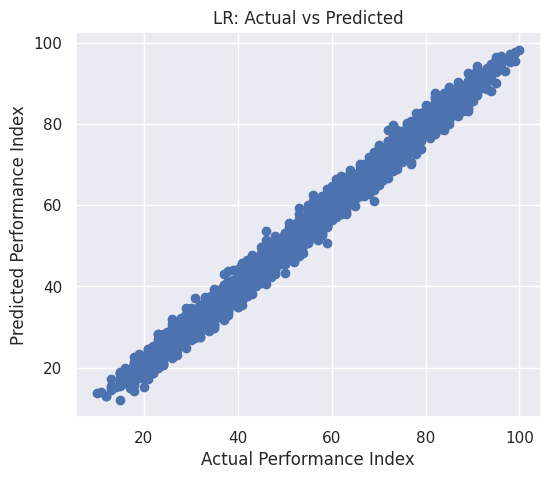

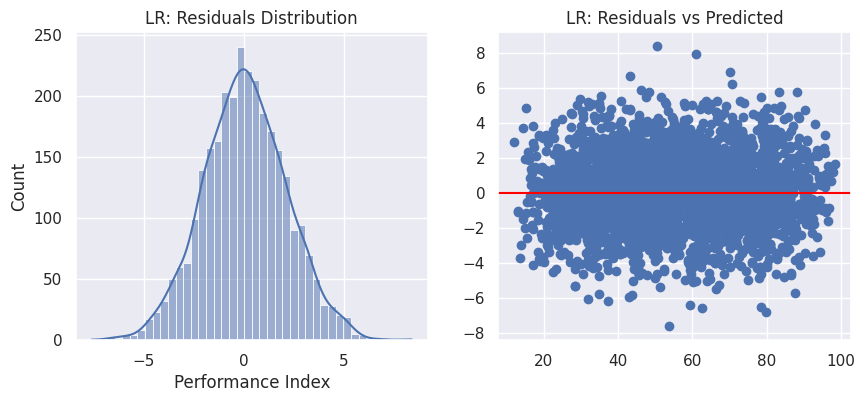

In [ ]:
#Apply models

# Linear Regression (with scaled data)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

start_train = time.time()
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_scaled)
train_time_lr = time.time() - start_train

start_test = time.time()
y_pred_lr_scaled = lr.predict(X_test_scaled)
test_time_lr = time.time() - start_test

y_pred_lr = scaler_y.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).ravel()

print("Linear Regression Performance:")
print("R² Score:", round(r2_score(y_test, y_pred_lr), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 2))
print("MAE:", round(mean_absolute_error(y_test, y_pred_lr), 2))
print("\n" + "="*50)
print("TIMING:")
print(f"Training Time: {train_time_lr:.4f} seconds")
print(f"Testing Time: {test_time_lr:.4f} seconds")
print("="*50)

timing_data['Linear Regression'] = {
    'MAE': round(mean_absolute_error(y_test, y_pred_lr), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 2),
    'R2 Score': round(r2_score(y_test, y_pred_lr), 4),
    'Training Time (s)': round(train_time_lr, 4),
    'Testing Time (s)': round(test_time_lr, 4)
}

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("LR: Actual vs Predicted")
plt.show()

residuals_lr = y_test - y_pred_lr
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(residuals_lr, kde=True)
plt.title("LR: Residuals Distribution")
plt.subplot(1, 2, 2)
plt.scatter(y_pred_lr, residuals_lr)
plt.axhline(0, color='red')
plt.title("LR: Residuals vs Predicted")
plt.show()

y_pred = lr.predict(X_test)

## SVR


SVR Model Performance:
R² Score: 0.988
RMSE: 2.09
MAE: 1.65

TIMING:
Training Time: 2.8478 seconds
Testing Time: 0.3155 seconds


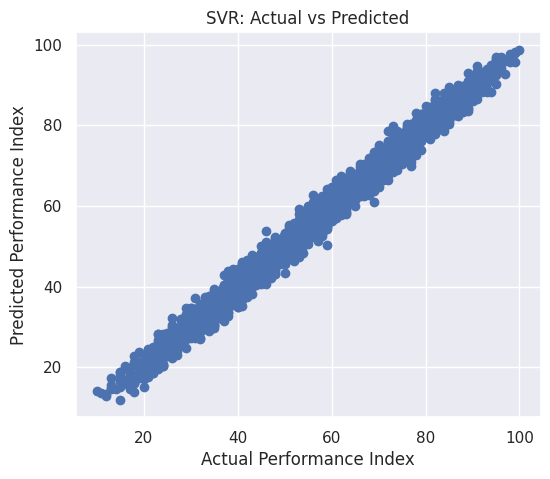

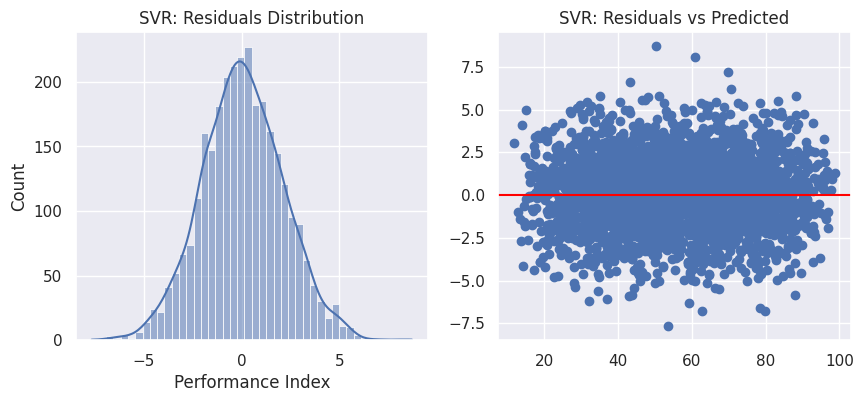

In [ ]:
from sklearn.svm import SVR

# svr = SVR()
start_train = time.time()
svr = SVR(kernel='rbf', C=100, gamma=0.01)
svr.fit(X_train_scaled, y_train_scaled)
train_time_svr = time.time() - start_train

start_test = time.time()
y_pred_svr_scaled = svr.predict(X_test_scaled)
test_time_svr = time.time() - start_test

# Inverse transform to original scale
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

print("\nSVR Model Performance:")
print("R² Score:", round(r2_score(y_test, y_pred_svr), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_svr)), 2))
print("MAE:", round(mean_absolute_error(y_test, y_pred_svr), 2))
print("\n" + "="*50)
print("TIMING:")
print(f"Training Time: {train_time_svr:.4f} seconds")
print(f"Testing Time: {test_time_svr:.4f} seconds")
print("="*50)

timing_data['SVR'] = {
    'MAE': round(mean_absolute_error(y_test, y_pred_svr), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_svr)), 2),
    'R2 Score': round(r2_score(y_test, y_pred_svr), 4),
    'Training Time (s)': round(train_time_svr, 4),
    'Testing Time (s)': round(test_time_svr, 4)
}

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("SVR: Actual vs Predicted")
plt.show()

residuals_svr = y_test - y_pred_svr
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(residuals_svr, kde=True)
plt.title("SVR: Residuals Distribution")
plt.subplot(1, 2, 2)
plt.scatter(y_pred_svr, residuals_svr)
plt.axhline(0, color='red')
plt.title("SVR: Residuals vs Predicted")
plt.show()

## Decision Tree Regressor

Decision Tree Performance:
R² Score: 0.975
RMSE: 3.05
MAE: 2.43

TIMING:
Training Time: 0.0268 seconds
Testing Time: 0.0025 seconds


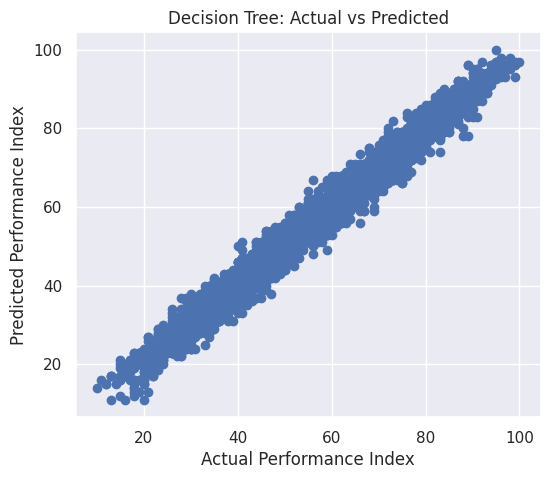

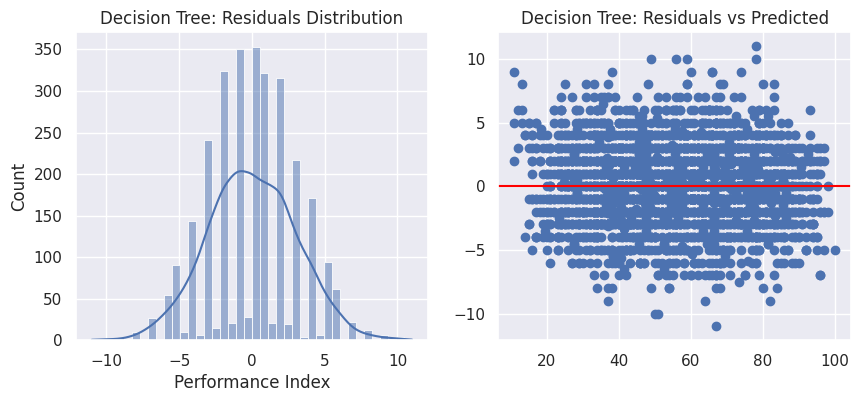

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# DECISION TREE REGRESSOR

start_train = time.time()
dt = DecisionTreeRegressor(max_depth=15, random_state=42)
dt.fit(X_train_scaled, y_train_scaled)
train_time_dt = time.time() - start_train

start_test = time.time()
y_pred_dt_scaled = dt.predict(X_test_scaled)
test_time_dt = time.time() - start_test

# Inverse transform to original scale
y_pred_dt = scaler_y.inverse_transform(y_pred_dt_scaled.reshape(-1, 1)).ravel()

print("Decision Tree Performance:")
print("R² Score:", round(r2_score(y_test, y_pred_dt), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 2))
print("MAE:", round(mean_absolute_error(y_test, y_pred_dt), 2))
print("\n" + "="*50)
print("TIMING:")
print(f"Training Time: {train_time_dt:.4f} seconds")
print(f"Testing Time: {test_time_dt:.4f} seconds")
print("="*50)

timing_data['Decision Tree'] = {
    'MAE': round(mean_absolute_error(y_test, y_pred_dt), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 2),
    'R2 Score': round(r2_score(y_test, y_pred_dt), 4),
    'Training Time (s)': round(train_time_dt, 4),
    'Testing Time (s)': round(test_time_dt, 4)
}

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

residuals_dt = y_test - y_pred_dt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(residuals_dt, kde=True)
plt.title("Decision Tree: Residuals Distribution")
plt.subplot(1, 2, 2)
plt.scatter(y_pred_dt, residuals_dt)
plt.axhline(0, color='red')
plt.title("Decision Tree: Residuals vs Predicted")
plt.show()

## RANDOM FOREST REGRESSOR

Random Forest Performance:
R² Score: 0.985
RMSE: 2.37
MAE: 1.89

TIMING:
Training Time: 1.5486 seconds
Testing Time: 0.1038 seconds


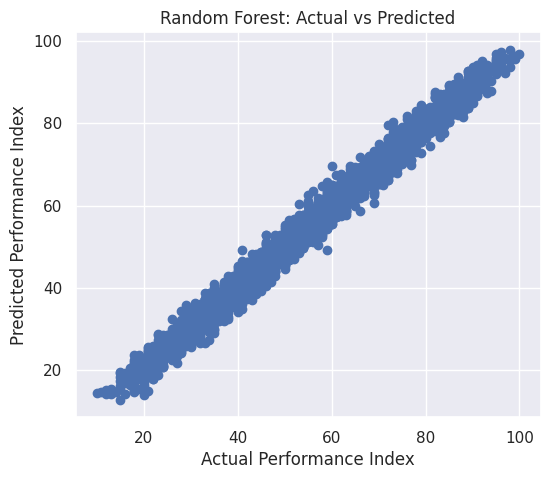

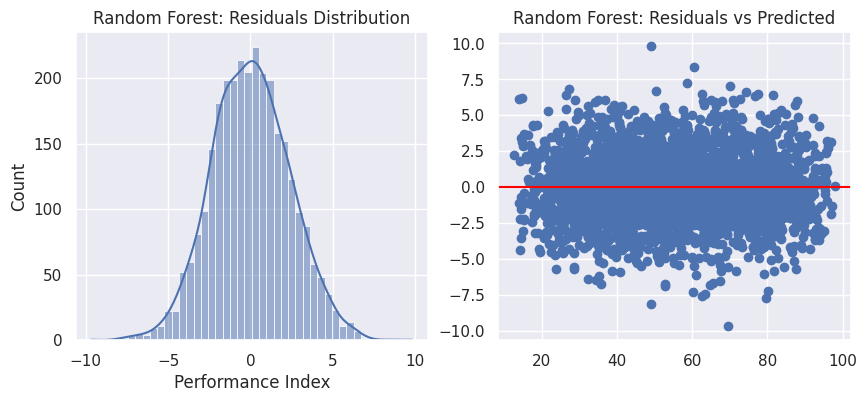


Random Forest Feature Importance:
                            Feature  Importance
1                   Previous Scores    0.846802
0                     Hours Studied    0.142197
3  Sample Question Papers Practiced    0.005058
2                       Sleep Hours    0.004672
4      Extracurricular Activities_1    0.001271


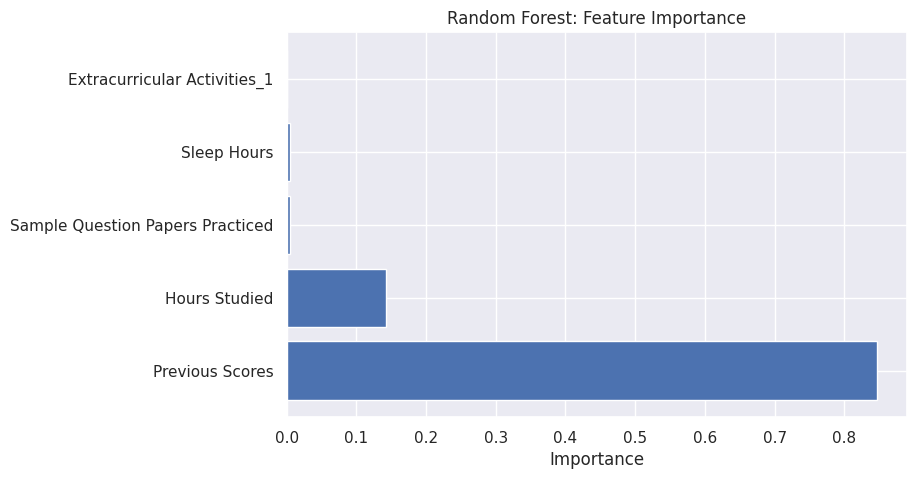

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# RANDOM FOREST REGRESSOR

start_train = time.time()
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf.fit(X_train_scaled, y_train_scaled)
train_time_rf = time.time() - start_train

start_test = time.time()
y_pred_rf_scaled = rf.predict(X_test_scaled)
test_time_rf = time.time() - start_test

# Inverse transform to original scale
y_pred_rf = scaler_y.inverse_transform(y_pred_rf_scaled.reshape(-1, 1)).ravel()

print("Random Forest Performance:")
print("R² Score:", round(r2_score(y_test, y_pred_rf), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2))
print("MAE:", round(mean_absolute_error(y_test, y_pred_rf), 2))
print("\n" + "="*50)
print("TIMING:")
print(f"Training Time: {train_time_rf:.4f} seconds")
print(f"Testing Time: {test_time_rf:.4f} seconds")
print("="*50)

timing_data['Random Forest'] = {
    'MAE': round(mean_absolute_error(y_test, y_pred_rf), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2),
    'R2 Score': round(r2_score(y_test, y_pred_rf), 4),
    'Training Time (s)': round(train_time_rf, 4),
    'Testing Time (s)': round(test_time_rf, 4)
}

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

residuals_rf = y_test - y_pred_rf
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(residuals_rf, kde=True)
plt.title("Random Forest: Residuals Distribution")
plt.subplot(1, 2, 2)
plt.scatter(y_pred_rf, residuals_rf)
plt.axhline(0, color='red')
plt.title("Random Forest: Residuals vs Predicted")
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.title("Random Forest: Feature Importance")
plt.show()

## KNN Regressor

KNN Performance:
R² Score: 0.974
RMSE: 3.06
MAE: 2.44

TIMING:
Training Time: 0.0123 seconds
Testing Time: 0.0458 seconds


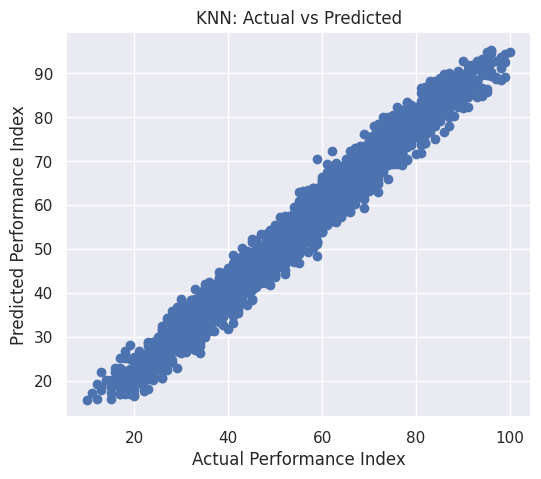

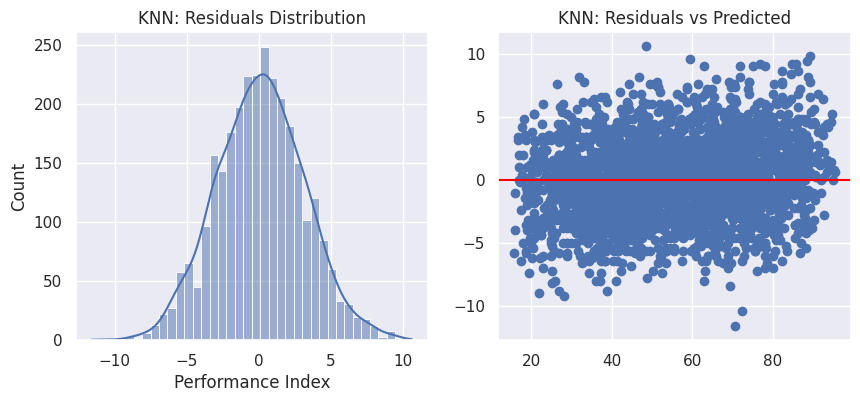

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# K-NEAREST NEIGHBORS REGRESSOR

start_train = time.time()
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train_scaled)
train_time_knn = time.time() - start_train

start_test = time.time()
y_pred_knn_scaled = knn.predict(X_test_scaled)
test_time_knn = time.time() - start_test

# Inverse transform to original scale
y_pred_knn = scaler_y.inverse_transform(y_pred_knn_scaled.reshape(-1, 1)).ravel()

print("KNN Performance:")
print("R² Score:", round(r2_score(y_test, y_pred_knn), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_knn)), 2))
print("MAE:", round(mean_absolute_error(y_test, y_pred_knn), 2))
print("\n" + "="*50)
print("TIMING:")
print(f"Training Time: {train_time_knn:.4f} seconds")
print(f"Testing Time: {test_time_knn:.4f} seconds")
print("="*50)

timing_data['KNN'] = {
    'MAE': round(mean_absolute_error(y_test, y_pred_knn), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_knn)), 2),
    'R2 Score': round(r2_score(y_test, y_pred_knn), 4),
    'Training Time (s)': round(train_time_knn, 4),
    'Testing Time (s)': round(test_time_knn, 4)
}

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("KNN: Actual vs Predicted")
plt.show()

residuals_knn = y_test - y_pred_knn
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(residuals_knn, kde=True)
plt.title("KNN: Residuals Distribution")
plt.subplot(1, 2, 2)
plt.scatter(y_pred_knn, residuals_knn)
plt.axhline(0, color='red')
plt.title("KNN: Residuals vs Predicted")
plt.show()

### Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?  

# Answer  

## 1. What is a Decision Tree Regressor?  
A Decision Tree Regressor is a tree-like model that makes predictions by recursively splitting the data based on feature values. It creates a hierarchical structure of decision rules that partition the feature space into regions, with each region assigned a target value (the average of data points in that region).  

The tree makes decisions by asking questions like:

"Is Hours Studied > 3?"  
"Is Previous Scores > 80?"  
"Is Sleep Hours > 6?"  

Each leaf node contains the average target value of all data points that reach it. When predicting a new value, the algorithm follows the decision rules from root to leaf and outputs that leaf's value.  

## Example Decision Tree:  
IF Hours Studied > 3:  

    IF Previous Scores > 80:  
        Prediction = 85  
    ELSE:  
        Prediction = 70    


ELSE:  

    IF Sleep Hours > 6:  
        Prediction = 60  
    ELSE:  
        Prediction = 45    
## 2. What is Bootstrapping?  
Bootstrapping is a sampling technique that creates multiple random samples from the original dataset with replacement. This means:

1. Each sample has the same size as the original dataset  
2. Some data points appear multiple times  
3. Some data points don't appear at all  
4. Each sample is slightly different from the original  

## 3. How Multiple Trees are Used?
Random Forest grows multiple independent decision trees (typically 100+), each trained on a different bootstrap sample. The key is that each tree is built independently and captures different patterns in the data.  

## 4. How Final Output is Calculated?
For regression tasks, the final prediction is the arithmetic mean (average) of all individual tree predictions:  
Final Prediction = (Prediction₁ + Prediction₂ + ... + Prediction₁₀₀) / 100

### Answer the follwing

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?  
# Answer

## 1. What is K?  
K is the number of nearest neighbors to consider when making a prediction. For example:  
K=5 means the algorithm looks at the 5 closest neighbors to make a prediction  
K=1 means it only considers the single closest neighbor  
Larger K values smooth the predictions, smaller K values make them more sensitive to individual data points  

## 2. How Neighbors are Selected?  
KNN selects neighbors based on distance metric (usually Euclidean distance):  
Distance = √[(x₁-x₂)² + (y₁-y₂)² + (z₁-z₂)² + ...]  
Steps t select the neighbor:

1. Calculate the distance from the new data point to all training data points
2. Sort distances in ascending order
3. Select the K closest neighbors (smallest distances)

## 3. How Final Predicted Value is Calculated?
For regression, the final prediction is simply the average of the target values of K neighbors:  
Predicted Value = (y₁ + y₂ + y₃ + ... + yₖ) / K

## Visualize Best Model

In [ ]:
# Select best model based on R2

# Create comparison dataframe
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR', 'KNN', 'Decision Tree', 'Random Forest'],
    'R² Score': [
        round(r2_score(y_test, y_pred_lr), 4),
        round(r2_score(y_test, y_pred_svr), 4),
        round(r2_score(y_test, y_pred_knn), 4),
        round(r2_score(y_test, y_pred_dt), 4),
        round(r2_score(y_test, y_pred_rf), 4)
    ],
    'RMSE': [
        round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_svr)), 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_knn)), 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2)
    ],
    'MAE': [
        round(mean_absolute_error(y_test, y_pred_lr), 2),
        round(mean_absolute_error(y_test, y_pred_svr), 2),
        round(mean_absolute_error(y_test, y_pred_knn), 2),
        round(mean_absolute_error(y_test, y_pred_dt), 2),
        round(mean_absolute_error(y_test, y_pred_rf), 2)
    ]
})

print("="*70)
print("ALL MODELS PERFORMANCE COMPARISON")
print("="*70)
print(models_comparison.to_string(index=False))

# Identify best model (highest R² Score)
best_model_idx = models_comparison['R² Score'].idxmax()
best_model_name = models_comparison.loc[best_model_idx, 'Model']
best_r2 = models_comparison.loc[best_model_idx, 'R² Score']

print("\n" + "="*70)
print(f" BEST MODEL: {best_model_name}")
print(f"R² Score: {best_r2}")
print("="*70)

ALL MODELS PERFORMANCE COMPARISON
            Model  R² Score  RMSE  MAE
Linear Regression    0.9882  2.08 1.65
              SVR    0.9881  2.09 1.65
              KNN    0.9743  3.06 2.44
    Decision Tree    0.9746  3.05 2.43
    Random Forest    0.9846  2.37 1.89

 BEST MODEL: Linear Regression
R² Score: 0.9882


## Generate a Comparison Table of Regression Models

Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---

In [ ]:
df_timing = pd.DataFrame(timing_data).T
df_timing = df_timing[['MAE', 'RMSE', 'R2 Score', 'Training Time (s)', 'Testing Time (s)']]

print("\n" + "="*110)
print("COMPLETE MODEL COMPARISON")
print("="*110 + "\n")
print(df_timing.to_string())

print("\n" + "="*110)
print("FOR MARKDOWN FORMAT")
print("="*110 + "\n")
print(df_timing.to_markdown())


COMPLETE MODEL COMPARISON

                    MAE  RMSE  R2 Score  Training Time (s)  Testing Time (s)
Linear Regression  1.65  2.08    0.9882             0.0046            0.0028
SVR                1.65  2.09    0.9881             2.8478            0.3155
Decision Tree      2.43  3.05    0.9746             0.0268            0.0025
Random Forest      1.89  2.37    0.9846             1.5486            0.1038
KNN                2.44  3.06    0.9743             0.0123            0.0458

FOR MARKDOWN FORMAT

|                   |   MAE |   RMSE |   R2 Score |   Training Time (s) |   Testing Time (s) |
|:------------------|------:|-------:|-----------:|--------------------:|-------------------:|
| Linear Regression |  1.65 |   2.08 |     0.9882 |              0.0046 |             0.0028 |
| SVR               |  1.65 |   2.09 |     0.9881 |              2.8478 |             0.3155 |
| Decision Tree     |  2.43 |   3.05 |     0.9746 |              0.0268 |             0.0025 |
| Random Fore

# Final Output  

|                   |   MAE |   RMSE |   R2 Score |   Training Time (s) |   Testing Time (s) |
|:------------------|------:|-------:|-----------:|--------------------:|-------------------:|
| Linear Regression |  1.65 |   2.08 |     0.9882 |              0.0046 |             0.0028 |
| SVR               |  1.65 |   2.09 |     0.9881 |              2.8478 |             0.3155 |
| Decision Tree     |  2.43 |   3.05 |     0.9746 |              0.0268 |             0.0025 |
| Random Forest     |  1.89 |   2.37 |     0.9846 |              1.5486 |             0.1038 |
| KNN               |  2.44 |   3.06 |     0.9743 |              0.0123 |             0.0458 |